# VIC Demand Forecasting Under an Exogenous Shock 
## Executive Summary
### OLS vs GAM vs an OLS+intervention model, evaluated against Victoria's COVID-19 structural break

**In plain terms:** This notebook compares two ways of forecasting Victoria's electricity demand, and tests how each one responds when something disrupts the normal pattern using COVID as a real-world example.

**Purpose:** 
1) Examine the impact of using a Hybrid OLS-GAM model vs a traditional OLS model on predicting energy demand in response to weather. 
2) Demonstrate how forecasting models behave during an exogenous shock, using Victoria's 2020 lockdowns as a clean natural experiment.


**Workflow**
1. Pull Victoria energy demand data and Melbourne weather data
2. Fit baseline OLS and Hybrid-GAM models on pre-COVID data only
3. Compare the specification of the two model types.
4. Can we see when COVID happens? Detect the structural break via residual monitoring. Test whether a simple threshold rule would have flagged the break early
5. Add a COVID intervention term and compare forecasts
6. Quantify uncertainty with POE10/POE50/POE90 weather-year resampling

**Conclusions**
- There is a non-linear relationship between energy demand and weather.
- COVID is significant, but spotting it is obstructed by "Black Summer" - 2020's severe bushfires. 
- The best model of those tested is the Hybrid GAM-OLS with COVID fixed effect. 

**Future Extensions - if more time were available**
- Bring in PM2.5 (particulate matter) data. This is a good representation of air pollution, 
and will allow us to observe fire season in the data.
- Bring in techno-economic indicators. The most basic of these, GDP, is missing purely due to time.
Other indicators, such as appliance purchases, EV purchases, data centres, and solar panel 
usage are missing. 
- Examine the impact of using other machine learning models to explain non-linear relationships. 

## Terms Used in This Notebook
For those who are new to the technical side of forecasting or energy demand

**Models**
- **OLS (Ordinary Least Squares):** the standard "straight-line" regression — assumes each input affects demand by a constant amount.
- **GAM (Generalized Additive Model):** a more flexible model that lets each input's effect curve and bend, rather than forcing a straight line.
- **HDD / CDD (Heating / Cooling Degree Days):** how far a day's temperature sits below (HDD) or above (CDD) a comfort threshold. The standard way to turn raw temperature into a demand-relevant number.

**Model fit & diagnostics**
- **R² / pseudo-R²:** the share of demand variation the model explains (0-100%). Higher is better, but not the only thing that matters.
- **AIC:** a score that rewards better fit but penalizes unnecessary complexity. Lower is better; used to compare models fairly.
- **EDoF (Effective Degrees of Freedom):** how much "bend" a GAM model is using. Higher means a more flexible, wigglier curve.
- **Durbin-Watson statistic:** flags whether a model's errors are patterned over time (a sign something's still missing from the model), rather than random.
- **Jarque-Bera (JB) test, skew, kurtosis:** checks on whether a model's errors are shaped like a normal bell curve, or are lopsided / heavy-tailed.

**Forecast accuracy**
- **MAE (Mean Absolute Error) / RMSE (Root Mean Squared Error):** two ways of measuring average forecast error, in the same units as demand (MW). RMSE penalizes large misses more heavily than MAE.

**Forecasting concepts**
- **Structural break:** a point where the underlying relationship between inputs and demand actually changes, rather than just a one-off unusual day.
- **Fixed effect:** a simple way of letting a model account for a known event (like COVID) by adding a flag the model can use, rather than modelling the event's mechanics directly.
- **POE10 / POE50 / POE90:** standard AEMO terminology for probability-of-exceedance bands. See the dedicated explanation later in this notebook for how to read these.
- **Omitted-variable bias:** when leaving a relevant factor out of a model causes its other estimates to shift, because the model is compensating for the missing piece.


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pygam import LinearGAM, s, f
import pygam
from nemosis import dynamic_data_compiler

warnings.filterwarnings("ignore")


c:\Users\Grace\anaconda3\envs\aemo\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Configuration

In [2]:
REGION = "VIC1"
RAW_CACHE = "./raw_data_cache"

START_DATE = "2017/01/01 00:00:00"
END_DATE = "2022/12/31 00:00:00"
TRAIN_END = "2019-12-31"

COVID_START = "2020-03-01"
COVID_END = "2020-10-31"

# Estimates from a practioner's article on HDD and CDD. 
# With more point this could be investigated based on practices.
BASEPOINT_COLD = 15.0
BASEPOINT_HOT = 22.0

# This is the station AEMO uses - Melbourne (Olympic Park), BOM station 086338
# Note this is gridded reanalysis data, not the raw data AEMO uses 
LATITUDE = -37.826
LONGITUDE = 144.982

TIMEZONE = "Australia/Melbourne"


## Data Ingestion: AEMO Demand

In [3]:
def pull_demand():
    os.makedirs(RAW_CACHE, exist_ok=True)
    print("Downloading AEMO demand data...")
    return dynamic_data_compiler(
        START_DATE, END_DATE, "DISPATCHREGIONSUM", RAW_CACHE,
        select_columns=["SETTLEMENTDATE", "REGIONID", "TOTALDEMAND"],
        filter_cols=["REGIONID"],
        filter_values=([REGION],),
    )


def clean_demand(df):
    df = df.copy()
    df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
    df = df.sort_values("SETTLEMENTDATE").drop_duplicates("SETTLEMENTDATE").set_index("SETTLEMENTDATE")

    daily = (
        df["TOTALDEMAND"].resample("D").agg(["mean", "max", "min"])
        .rename(columns={"mean": "avg_demand_mw", "max": "max_demand_mw", "min": "min_demand_mw"})
    )
    daily.index.name = "date"
    return daily.reset_index()


## Data Ingestion: Melbourne Weather

In [4]:
def pull_temperature(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": LATITUDE,
        "longitude": LONGITUDE,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean",
        "timezone": TIMEZONE,
    }
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()["daily"]

    return pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temp_max_c": data["temperature_2m_max"],
        "temp_min_c": data["temperature_2m_min"],
        "temp_mean_c": data["temperature_2m_mean"],
    })


def add_degree_days(df):
    df = df.copy()
    df["hdd"] = (BASEPOINT_HOT - df["temp_mean_c"]).clip(lower=0)
    df["cdd"] = (df["temp_mean_c"] - BASEPOINT_COLD).clip(lower=0)
    return df


## Feature Engineering

In [5]:
def build_dataset():
    demand = clean_demand(pull_demand())

    weather = pull_temperature(
        demand["date"].min().strftime("%Y-%m-%d"),
        demand["date"].max().strftime("%Y-%m-%d"),
    )
    weather = add_degree_days(weather)

    df = demand.merge(weather, on="date", how="left")

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["trend"] = df["year"] - df["year"].min()
    df["covid_period"] = ((df["date"] >= COVID_START) & (df["date"] <= COVID_END)).astype(int)

    return df.dropna()


## Model Specifications: OLS, OLS+COVID, Hybrid OLS+GAM, Hybrid OLS+GAM+COVID

In [6]:
def fit_ols(df):
    return smf.ols(
        "max_demand_mw ~ hdd + cdd + C(month) + is_weekend + trend", data=df
    ).fit()


def fit_ols_covid(df):
    return smf.ols(
        "max_demand_mw ~ hdd + cdd + C(month) + is_weekend + trend + covid_period", data=df
    ).fit()

GAM_FEATURES = ["hdd", "cdd", "month", "is_weekend", "trend"]
GAM_FEATURES_COVID = GAM_FEATURES + ["covid_period"]


def fit_hybrid_gam(df):
    X = df[GAM_FEATURES]
    y = df["max_demand_mw"]
    model = pygam.LinearGAM(
        pygam.s(0) + pygam.s(1) + pygam.f(2) + pygam.f(3) + pygam.s(4)
    )   
    model.fit(X, y)
    return model


def fit_hybrid_gam_covid(df):
    X = df[GAM_FEATURES_COVID]
    y = df["max_demand_mw"]
    model = pygam.LinearGAM(
    pygam.s(0) + pygam.s(1) + pygam.f(2) + pygam.f(3) + pygam.s(4) + pygam.f(5)
    )
    model.fit(X, y)
    return model


def predict_hybrid_gam(model, df, features):
    """features must match what the model was fit with: GAM_FEATURES for
    fit_hybrid_gam, GAM_FEATURES_COVID for fit_hybrid_gam_covid."""
    return model.predict(df[features])


## Residual Monitoring Utility

In [7]:
def compute_threshold_diagnostics(df, model, predict_fn=None, search_start=None):
    """search_start: only look for the reportable 'first breach' on or
    after this date. Otherwise the earliest breach in the WHOLE series
    wins, which can be an early-data artifact unrelated to the period
    you actually care about."""
    predict_fn = predict_fn or (lambda m, d: m.predict(d))
    out = df.sort_values("date").copy()
    out["prediction"] = predict_fn(model, out)
    out["residual"] = out["max_demand_mw"] - out["prediction"]
    out["rolling_bias"] = out["residual"].rolling(window=30, center=True).mean()

    pre_covid_rolling = out.loc[out["covid_period"] == 0, "rolling_bias"].dropna()
    threshold = -2 * pre_covid_rolling.std()
    out["breach"] = out["rolling_bias"] < threshold

    # False-alarm baseline: how often does this threshold trip in normal years?
    pre_covid_breach_days = int(out.loc[out["covid_period"] == 0, "breach"].sum())

    search_df = out if search_start is None else out[out["date"] >= search_start]
    breach = search_df[search_df["breach"]]
    first_breach_date = breach["date"].min() if not breach.empty else None

    return out, threshold, first_breach_date, pre_covid_breach_days
def plot_threshold_comparison(df, models, search_start=None):
    """models: list of (name, model, predict_fn) tuples. predict_fn may
    be None to default to model.predict(df).

    search_start: only report a 'first breach' on or after this date, so
    an early-data artifact at the start of the series doesn't mask
    whatever's actually happening near the period you care about. The
    full rolling-bias line is still plotted for the whole history either
    way -- only the reported breach date is restricted.
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ["#C00000", "#4472C4", "#70AD47"]
    summary = []

    for (name, model, predict_fn), color in zip(models, colors):
        out, threshold, first_breach_date, pre_covid_breach_days = compute_threshold_diagnostics(
            df, model, predict_fn, search_start=search_start
        )

        ax.plot(out["date"], out["rolling_bias"], color=color, linewidth=2.5, label=f"{name} rolling bias")
        ax.axhline(threshold, color=color, linestyle=":", linewidth=1.3,
                   label=f"{name} threshold ({threshold:.0f} MW)")
        if first_breach_date is not None:
            ax.axvline(first_breach_date, color=color, linewidth=1.2, alpha=0.7)

        summary.append({
            "model": name,
            "threshold_mw": threshold,
            "first_breach": first_breach_date,
            "pre_covid_false_alarm_days": pre_covid_breach_days,
        })

    ax.axhline(0, color="black", linewidth=1)
    ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), color="grey", alpha=0.12,
               label="COVID disruption period")

    if search_start is not None:
        ax.axvline(pd.Timestamp(search_start), color="black", linestyle="--", linewidth=1, alpha=0.4,
                   label=f"Search start ({search_start})")

    ax.set_title("OLS vs Hybrid-GAM: how quickly would each have flagged the COVID break?")
    ax.set_ylabel("30-day rolling forecast bias (MW)")
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("ols_vs_hybrid_threshold_comparison.png", dpi=150)
    plt.show()

    for row in summary:
        print(f"{row['model']}: {row['pre_covid_false_alarm_days']} breach-day(s) in non-COVID "
              f"training years (false-alarm baseline)")
        if row["first_breach"] is not None:
            days = (pd.Timestamp(COVID_START) - row["first_breach"]).days
            timing = "before" if days > 0 else "after"
            print(f"{row['model']}: first reportable breach on {row['first_breach'].date()} "
                  f"({abs(days)} days {timing} official COVID_START)")
        else:
            print(f"{row['model']}: never breached threshold in this search window.")

    return pd.DataFrame(summary)

## Probabilistic Peak Forecasts: POE10 / POE50 / POE90

In [8]:
def poe_from_simulations(values):
    return {
        "POE10": np.percentile(values, 90),
        "POE50": np.percentile(values, 50),
        "POE90": np.percentile(values, 10),
    }


def prepare_simulation_inputs(weather_trace, target_trend):
    sim = weather_trace.copy()
    sim["trend"] = target_trend
    return sim


def simulate_peak_distribution(model, train_df, target_year, model_type="ols"):
    """
    Resample each pre-shock weather year onto target_year's trend value and
    predict the resulting peak demand, building a distribution of
    "what if we'd had that year's weather instead" outcomes.

    Note: for the intervention model, covid_period is left at its original
    (zero) value in every historical trace -- so this produces a
    counterfactual "normal weather, no shock" band, which is exactly what
    you want to compare against what actually happened.
    """
    target_trend = target_year - train_df["year"].min()
    peaks = []

    for year in sorted(train_df["year"].unique()):
        weather_trace = train_df[train_df["year"] == year]
        sim = prepare_simulation_inputs(weather_trace, target_trend)

        if model_type == "ols":
            prediction = model.predict(sim)
        elif model_type == "gam":
            prediction = predict_hybrid_gam(model, sim, GAM_FEATURES)
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        peaks.append(prediction.max())

    return poe_from_simulations(peaks)


## Visualisation Functions

In [9]:
def plot_residual_detection(df):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["date"], df["residual"], color="grey", alpha=0.5, label="Daily residual")
    ax.plot(df["date"], df["rolling_error"], color="red", linewidth=2, label="30-day rolling residual")
    ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), alpha=0.2, color="blue",
               label="COVID lockdown period")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Residual monitoring: detecting structural demand deviation")
    ax.set_ylabel("Actual - predicted demand (MW)")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("covid_residual_detection.png", dpi=150)
    plt.show()

def plot_model_predictions(df, ols, gam, ols_covid, gam_covid):
    plot_df = df.copy()
    plot_df["OLS"] = ols.predict(plot_df)
    plot_df["OLS_COVID"] = ols_covid.predict(plot_df)
    plot_df["GAM"] = predict_hybrid_gam(gam, plot_df, GAM_FEATURES)
    plot_df["GAM_COVID"] = predict_hybrid_gam(gam_covid, plot_df, GAM_FEATURES_COVID)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df["date"], plot_df["max_demand_mw"], color="black", alpha=0.4, label="Actual")
    ax.plot(plot_df["date"], plot_df["OLS"], label="OLS")
    ax.plot(plot_df["date"], plot_df["GAM"], label="GAM")
    ax.plot(plot_df["date"], plot_df["OLS_COVID"], label="OLS + COVID intervention", linewidth=2)
    ax.plot(plot_df["date"], plot_df["GAM_COVID"], label="GAM + COVID intervention", linewidth=2)
    ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), color="blue", alpha=0.15)
    ax.set_title("Forecast response to COVID structural shock")
    ax.set_ylabel("Peak demand (MW)")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("covid_model_comparison.png", dpi=150)
    plt.show()
    
def plot_poe(results):
    df = pd.DataFrame(results)
    fig, ax = plt.subplots(figsize=(7, 5))

    for i, row in df.iterrows():
        ax.plot([i, i], [row["POE90"], row["POE10"]], linewidth=15, alpha=0.3)
        ax.scatter(i, row["POE50"], color="black", s=50)

    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["model"])
    ax.set_ylabel("Peak demand (MW)")
    ax.set_title("Peak demand uncertainty: POE10 / POE50 / POE90")
    plt.tight_layout()
    plt.savefig("poe_model_comparison.png", dpi=150)
    plt.show()


def plot_weather_error_relationship(df, ols_model):
    """
    Check whether OLS residuals still contain nonlinear weather signal.
    Restricted to non-COVID rows so the plot isolates weather
    misspecification rather than the structural break itself.
    """
    plot_df = df[df["covid_period"] == 0].copy()
    plot_df["residual"] = plot_df["max_demand_mw"] - ols_model.predict(plot_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    panels = [(axes[0], "cdd", "#4472C4", "cooling"), (axes[1], "hdd", "#70AD47", "heating")]

    for ax, var, color, label in panels:
        ax.scatter(plot_df[var], plot_df["residual"], alpha=0.35, color=color, s=25)
        lowess = sm.nonparametric.lowess(plot_df["residual"], plot_df[var], frac=0.35)
        ax.plot(lowess[:, 0], lowess[:, 1], color="#C00000", linewidth=3, label="Residual trend")
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"Residuals vs {label} demand pressure")
        ax.set_xlabel(var.upper())
        ax.set_ylabel("OLS residual (MW)")
        ax.legend(frameon=False)
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle("Diagnosing OLS misspecification: weather signal left in residuals", fontsize=14)
    plt.tight_layout()
    plt.savefig("weather_residual_diagnostic.png", dpi=150)
    plt.show()


def plot_covid_structural_break(df, ols_model):
    """
    Show structural break detection through persistent forecast error
    during COVID, and test whether a simple threshold rule on rolling
    bias would have flagged the break before its cause was known.

    The point isn't to prove COVID caused the change -- it's to show the
    forecasting relationship changed, and ask whether that change was
    detectable in real time from forecast error alone.
    """
    plot_df = df.sort_values("date").copy()
    plot_df["prediction"] = ols_model.predict(plot_df)
    plot_df["residual"] = plot_df["max_demand_mw"] - plot_df["prediction"]
    plot_df["rolling_bias"] = plot_df["residual"].rolling(window=30, center=True).mean()

    # Calibrate the threshold on pre-COVID residual volatility -- that's
    # the "normal" regime an operational forecaster would actually have
    # available before the shock occurred.
    pre_covid_std = plot_df.loc[plot_df["covid_period"] == 0, "residual"].std()
    threshold = -2 * pre_covid_std

    breach = plot_df[plot_df["rolling_bias"] < threshold]
    first_breach_date = breach["date"].min() if not breach.empty else None

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(plot_df["date"], plot_df["residual"], color="#BFBFBF", s=12, alpha=0.5,
               label="Daily forecast error")
    ax.plot(plot_df["date"], plot_df["rolling_bias"], color="#C00000", linewidth=3,
            label="30-day rolling bias")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(threshold, color="#C00000", linestyle=":", linewidth=1.5,
               label=f"Threshold: -2\u00d7 pre-COVID residual SD ({threshold:.0f} MW)")
    ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), color="#4472C4", alpha=0.15,
               label="COVID disruption period")

    if first_breach_date is not None:
        ax.axvline(first_breach_date, color="black", linewidth=1.5)
        ax.annotate(f"First breach: {first_breach_date.date()}",
                    (first_breach_date, plot_df["rolling_bias"].min()),
                    textcoords="offset points", xytext=(8, 0), fontsize=9)

    ax.set_title("Detecting structural change through forecast error monitoring")
    ax.set_ylabel("Actual demand - OLS forecast (MW)")
    ax.set_xlabel("Date")
    ax.legend(frameon=False, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("covid_structural_break_detection.png", dpi=150)
    plt.show()

    if first_breach_date is not None:
        days_relative = (pd.Timestamp(COVID_START) - first_breach_date).days
        timing = "before" if days_relative > 0 else "after"
        print(f"Threshold first breached on {first_breach_date.date()} "
              f"({abs(days_relative)} days {timing} the official COVID_START date).")
    else:
        print("Rolling bias never breached the threshold in this window.")


## Build the Dataset

In [10]:
print("Building VIC demand dataset...")
df = build_dataset()
print(f"Dataset spans {df['date'].min().date()} to {df['date'].max().date()}")


Building VIC demand dataset...
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Downloading data for table DISPATCHREGIONSUM, year 2016, month 12
INFO: Creating feather file for DISPATCHREGIONSUM, 2016, 12
INFO: Downloading data for table DISPATCHREGIONSUM, year 2017, month 01
INFO: Creating feather file for DISPATCHREGIONSUM, 2017, 01
INFO: Downloading data for table DISPATCHREGIONSUM, year 2017, month 02
INFO: Creating feather file for DISPATCHREGIONSUM, 2017, 02
INFO: Downloading data for table DISPATCHREGIONSUM, year 2017, month 03
INFO: Creating feather file for DISPATCHREGIONSUM, 2017, 03
INFO: Downloading data for table DISPATCHREGIONSUM, year 2017, month 04
INFO: Creating feather file for DISPATCHREGIONSUM, 2017, 04
INFO: Downloading data for table DISPATCHREGIONSUM, year 2017, month 05
INFO: Creating feather file for DISPATCHREGIONSUM, 2017, 05
INFO: Downloading data for table DISPATCHREGIONSUM, year 2017, month 06
INFO: Creating feather file for DISPATCHREGIONSUM, 2017,

## Train / Test Split

Training data is restricted to pre-COVID years (2017-2019) so the baseline models have no information about the shock. The COVID evaluation window captures the 2020 disruption directly.

In [11]:
train = df[df["date"] <= TRAIN_END].copy()
covid_test = df[(df["date"] >= COVID_START) & (df["date"] <= "2020-12-31")].copy()

print(f"Training period: {train['date'].min().date()} - {train['date'].max().date()}")
print(f"COVID evaluation: {covid_test['date'].min().date()} - {covid_test['date'].max().date()}")


Training period: 2017-01-01 - 2019-12-31
COVID evaluation: 2020-03-01 - 2020-12-31


## Fit Baseline Models (Pre-COVID Only): OLS

### How it fits:
- **High R²**: 80.9% of the data is explained by the OLS model. 
- **Significant weather coefficients**: HDD and CDD have significantly strong coefficients and are significant at the 99th percentile.
- **Mostly significant month coefficients**: Month coefficients point in explainable directions. Winter months exhibit substantially higher demand than January after controlling for HDD/CDD, while several spring and late-year months exhibit lower demand than January. The non-significant months - Feb, March, April - are transient months with less predictable weather. In a future analysis, an interaction between HDDxMonth and CDDxMonth could be included to see if season unpredictability explains the lack of significance for certain months. 
- **Non-normal residuals** - Residuals are skewed (-0.182), showing the model underpredicts large negative deviations more than positive ones. JB p-value of approximately zero shows that we reject the hypothesis that residuals are normally distributed. Kurtosis of 4.3 (normal = 3), which suggests heavier tails than a normal distribution.
- **Auto-correlated residuals** - The Durbin-Watson statistic of 1.228 indicates positive autocorrelation in residuals, implying that some temporal structure remains unexplained by the model.

### Conclusion:
OLS alone is not fully explaining demand. **While weather (HDD and CDD) explains most demand variation, the relationship is strongly non-linear.** We can bring in GAM (Generalized Additive Model) to improve this prediction.


In [12]:
print("Fitting baseline OLS and GAM models...")
ols = fit_ols(train)
print(ols.summary().as_text())


Fitting baseline OLS and GAM models...
                            OLS Regression Results                            
Dep. Variable:          max_demand_mw   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     303.7
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:13:58   Log-Likelihood:                -8077.4
No. Observations:                1095   AIC:                         1.619e+04
Df Residuals:                    1079   BIC:                         1.627e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Inter

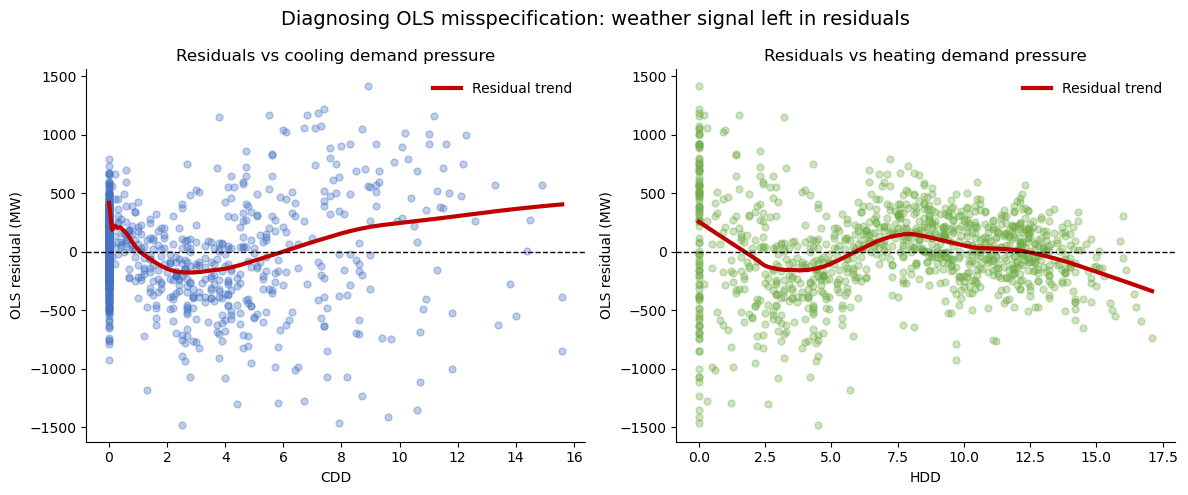

In [13]:
plot_weather_error_relationship(train, ols)


## Fit Hybrid Model (Pre-COVID Only): GAM + Calendar Effects

### How it fits:

* **Improved explanatory power**: Allowing weather variables to enter as smooth nonlinear functions improves model performance, increasing pseudo-R² from **80.9%** in the OLS model to **83.8%**. The model also achieves a lower AIC (16,190 vs. 16,062), indicating that the additional flexibility is justified by improved fit.
* **Nonlinear weather effects**: Both HDD and CDD exhibit clear nonlinear relationships with electricity demand. The HDD smooth has an effective degrees of freedom (EDoF) of 15.0, while the CDD smooth has an EDoF of 5.7. This can be more clearly seen on the chart, where the curves of HDD and CDD are non-monotonic. This suggests that demand does not respond to temperature changes at a constant rate. Instead, weather impacts appear to accelerate or change shape at different levels of heating and cooling demand.
* **Strong seasonal effects remain**: Month effects remain highly significant even after allowing for nonlinear weather responses. This indicates that weather alone does not fully explain seasonality. Additional factors such as daylight hours, household behaviour, business activity, and seasonal consumption patterns may also influence demand.
* **Strong weekend effect**: Weekend effects remain highly significant, confirming that behavioural and economic factors continue to play an important role in electricity consumption. Demand remains substantially lower on weekends after controlling for weather and seasonality.
* **Little evidence of underlying trend**: The smooth trend term contributes very little explanatory power (EDoF ≈ 2.0) and is not statistically significant. Consistent with the OLS results, there is little evidence of a systematic increase or decrease in electricity demand during the pre-COVID period once weather and seasonal effects are accounted for.
* **Evidence that weather drives model improvement**: The largest increase in model performance comes from allowing HDD and CDD to vary nonlinearly. This suggests that the primary limitation of the OLS model was not omitted seasonality or trend effects, but rather the assumption that demand responds linearly to temperature.

### Conclusion:

**The hybrid GAM confirms that weather is the dominant driver of electricity demand but shows that the relationship is more complex than a simple linear model can capture.** Demand responds nonlinearly to both heating and cooling requirements, with the strongest gains coming from improved modelling of weather effects. While the improvement in explanatory power is modest, the lower AIC and the shape of the estimated smooth functions suggest that the GAM provides a more realistic representation of electricity demand dynamics than OLS. These results support the use of nonlinear weather terms in subsequent forecasting and policy analysis.


In [14]:
gam = fit_hybrid_gam(train)
print(gam.summary())


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      34.423
Link Function:                     IdentityLink Log Likelihood:                                 -7987.9612
Number of Samples:                         1095 AIC:                                            16046.7684
                                                AICc:                                            16049.206
                                                GCV:                                           138901.4098
                                                Scale:                                             362.028
                                                Pseudo R-Squared:                                   0.8375
Feature Function                  Lam

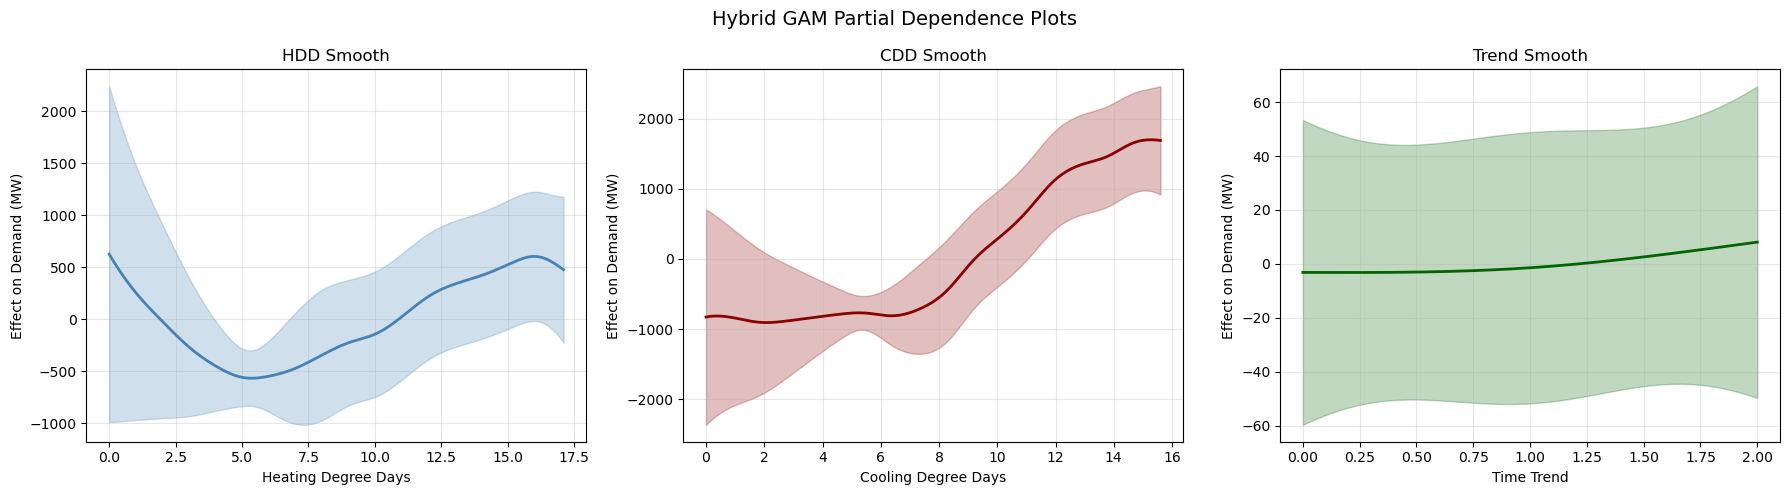

In [15]:
# Feature matrix used in model fitting
X = train[["hdd", "cdd", "month", "is_weekend", "trend"]]


# Need to calculate partial dependence because of pygam quirk.
# ------------------------
# HDD Partial Dependence
# ------------------------

hdd_grid = np.linspace(X["hdd"].min(), X["hdd"].max(), 200)

X_hdd = np.tile(X.mean().values, (200, 1))
X_hdd[:, 0] = hdd_grid

# Set valid categorical values
X_hdd[:, 2] = 6      # June
X_hdd[:, 3] = 0      # Weekday

hdd_effect, hdd_ci = gam.partial_dependence(
    term=0,
    X=X_hdd,
    width=0.95
)

# ------------------------
# CDD Partial Dependence
# ------------------------

cdd_grid = np.linspace(X["cdd"].min(), X["cdd"].max(), 200)

X_cdd = np.tile(X.mean().values, (200, 1))
X_cdd[:, 1] = cdd_grid

# Set valid categorical values
X_cdd[:, 2] = 1      # January
X_cdd[:, 3] = 0      # Weekday

cdd_effect, cdd_ci = gam.partial_dependence(
    term=1,
    X=X_cdd,
    width=0.95
)

# ==========================================================
# Trend smooth (term 4)
# ==========================================================

trend_grid = np.linspace(
    X["trend"].min(),
    X["trend"].max(),
    200
)

X_trend = np.tile(X.mean().values, (200, 1))
X_trend[:, 4] = trend_grid

X_trend[:, 2] = 6    # month = June
X_trend[:, 3] = 0    # weekday

trend_effect, trend_ci = gam.partial_dependence(
    term=4,
    X=X_trend,
    width=0.95
)

# ==========================================================
# Center curves for easier interpretation
# ==========================================================
hdd_shift = np.mean(hdd_effect)
hdd_effect -= hdd_shift
hdd_ci -= hdd_shift # aaand confidence intervals

cdd_shift = np.mean(cdd_effect)
cdd_effect -= cdd_shift
cdd_ci -= cdd_shift

trend_shift = np.mean(trend_effect)
trend_effect -= trend_shift
trend_ci -= trend_shift

# ------------------------
# Plot
# ------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# HDD
axes[0].plot(
    hdd_grid,
    hdd_effect,
    color="steelblue",
    linewidth=2
)

axes[0].fill_between(
    hdd_grid,
    hdd_ci[:, 0],
    hdd_ci[:, 1],
    color="steelblue",
    alpha=0.25
)

axes[0].set_title("HDD Smooth")
axes[0].set_xlabel("Heating Degree Days")
axes[0].set_ylabel("Effect on Demand (MW)")
axes[0].grid(alpha=0.3)

# CDD
axes[1].plot(
    cdd_grid,
    cdd_effect,
    color="darkred",
    linewidth=2
)

axes[1].fill_between(
    cdd_grid,
    cdd_ci[:, 0],
    cdd_ci[:, 1],
    color="darkred",
    alpha=0.25
)

axes[1].set_title("CDD Smooth")
axes[1].set_xlabel("Cooling Degree Days")
axes[1].set_ylabel("Effect on Demand (MW)")
axes[1].grid(alpha=0.3)

# Trend
axes[2].plot(
    trend_grid,
    trend_effect,
    color="darkgreen",
    linewidth=2
)

axes[2].fill_between(
    trend_grid,
    trend_ci[:, 0],
    trend_ci[:, 1],
    color="darkgreen",
    alpha=0.25
)

axes[2].set_title("Trend Smooth")
axes[2].set_xlabel("Time Trend")
axes[2].set_ylabel("Effect on Demand (MW)")
axes[2].grid(alpha=0.3)

plt.suptitle(
    "Hybrid GAM Partial Dependence Plots",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Detecting the Structural Break: Residual Monitoring Through COVID

To test whether a simple operational rule could have flagged the COVID disruption in real time, we calibrate a threshold on each model's own pre-COVID forecast volatility: 2 standard deviations below the typical 30-day rolling forecast bias.

Under normal conditions, about 95% of day-to-day forecast bias falls within +/-2 standard deviations of zero. A breach below -2 SD means we're seeing an outcome from roughly the bottom 2.5% of what we'd expect if nothing unusual were happening - a rare outcome. 

If we were forecasters at the beginning of 2020 with no knowledge of COVID, could we have seen it coming? Is this a good threshold? Note that this same threshold also trips a couple of times during the 2017-2019 training years, demonstrating the sensitivity of the test. A real deployment would likely want a stricter rule, such as requiring the breach to persist for several weeks, to avoid false alarms during ordinary winters and summers.

### Note: Disentangling Bushfire Smoke from the COVID Structural Break

The 2019-2020 bushfire season was known as "Black Summer" for a reason: I was there, and the air quality was horrendous.

Our detector's breach lands on January 6-8, 2020, more than two weeks before Australia's first confirmed COVID-19 case on January 25. **Whatever the detector is picking up, it cannot be COVID; the bushfire smoke crisis, which peaked around New Year's, is more likely.**

In a future analysis it would be nice to bring in air quality data (PM2.5) and techno-economic indicators (monthly GDP, foot traffic, appliance purchases, etc) to confirm this more directly.


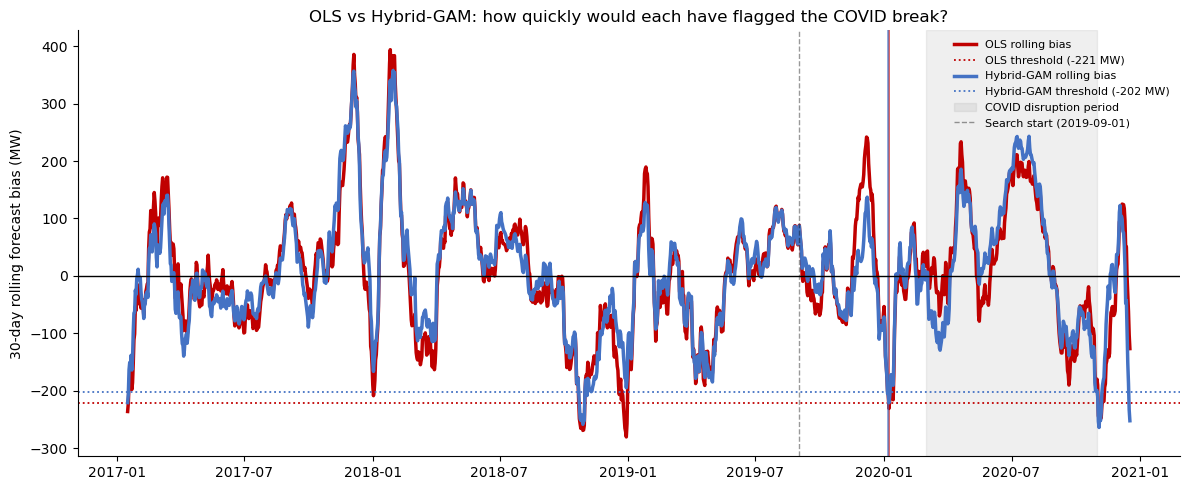

OLS: 23 breach-day(s) in non-COVID training years (false-alarm baseline)
OLS: first reportable breach on 2020-01-08 (53 days before official COVID_START)
Hybrid-GAM: 24 breach-day(s) in non-COVID training years (false-alarm baseline)
Hybrid-GAM: first reportable breach on 2020-01-06 (55 days before official COVID_START)


In [16]:
covid_window = df[df["date"] <= "2020-12-31"]

threshold_summary = plot_threshold_comparison(
    covid_window,
    [("OLS", ols, None), ("Hybrid-GAM", gam, lambda m, d: predict_hybrid_gam(m, d, GAM_FEATURES))],
    search_start="2019-09-01",
)

## Adding a COVID Intervention Term

We represent the presence of COVID in both models via a fixed effect. 

It's difficult to see the impact of the fixed effect in the 'Forecast response to COVID shock' graphs, but the residuals graphs are clearer. They demonstrate how accounting for COVID improves the model. If the relationship were fully explained by the included variables and functions, this line would be flat. It is not, but the Hybrid GAM model does a better job of accounting for COVID impact.

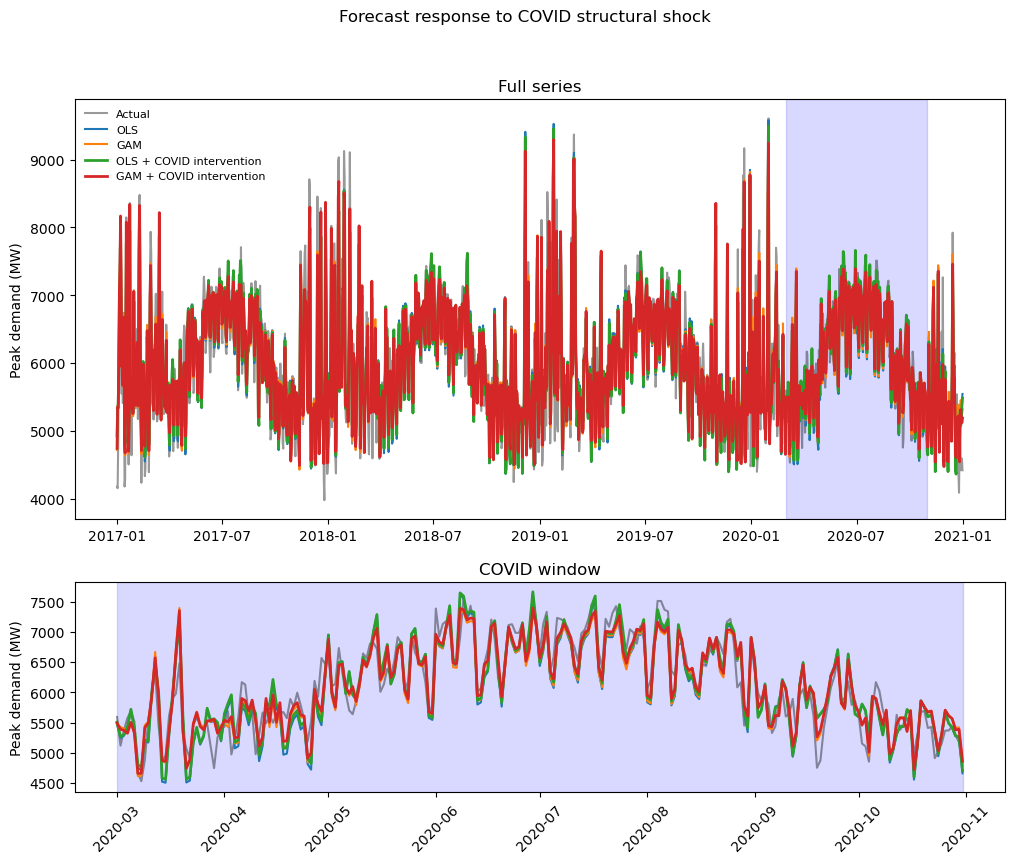

In [17]:
def plot_model_predictions(df, ols, gam, ols_covid, gam_covid):
    plot_df = df.copy()
    plot_df["OLS"] = ols.predict(plot_df)
    plot_df["OLS_COVID"] = ols_covid.predict(plot_df)
    plot_df["GAM"] = predict_hybrid_gam(gam, plot_df, GAM_FEATURES)
    plot_df["GAM_COVID"] = predict_hybrid_gam(gam_covid, plot_df, GAM_FEATURES_COVID)

    covid_df = plot_df[(plot_df["date"] >= COVID_START) & (plot_df["date"] <= COVID_END)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={"height_ratios": [2, 1]})

    for ax, data in zip(axes, [plot_df, covid_df]):
        ax.plot(data["date"], data["max_demand_mw"], color="black", alpha=0.4, label="Actual")
        ax.plot(data["date"], data["OLS"], label="OLS")
        ax.plot(data["date"], data["GAM"], label="GAM")
        ax.plot(data["date"], data["OLS_COVID"], label="OLS + COVID intervention", linewidth=2)
        ax.plot(data["date"], data["GAM_COVID"], label="GAM + COVID intervention", linewidth=2)
        ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), color="blue", alpha=0.15)

    axes[0].set_title("Full series")
    axes[0].set_ylabel("Peak demand (MW)")
    axes[0].legend(frameon=False, fontsize=8)

    axes[1].set_title("COVID window")
    axes[1].set_ylabel("Peak demand (MW)")
    axes[1].tick_params(axis="x", rotation=45)

    fig.suptitle("Forecast response to COVID structural shock")
    plt.show()

ols_covid = fit_ols_covid(df[df["date"] <= "2020-12-31"])
gam_covid = fit_hybrid_gam_covid(df[df["date"] <= "2020-12-31"])

plot_model_predictions(df[df["date"] <= "2020-12-31"], ols, gam, ols_covid, gam_covid)

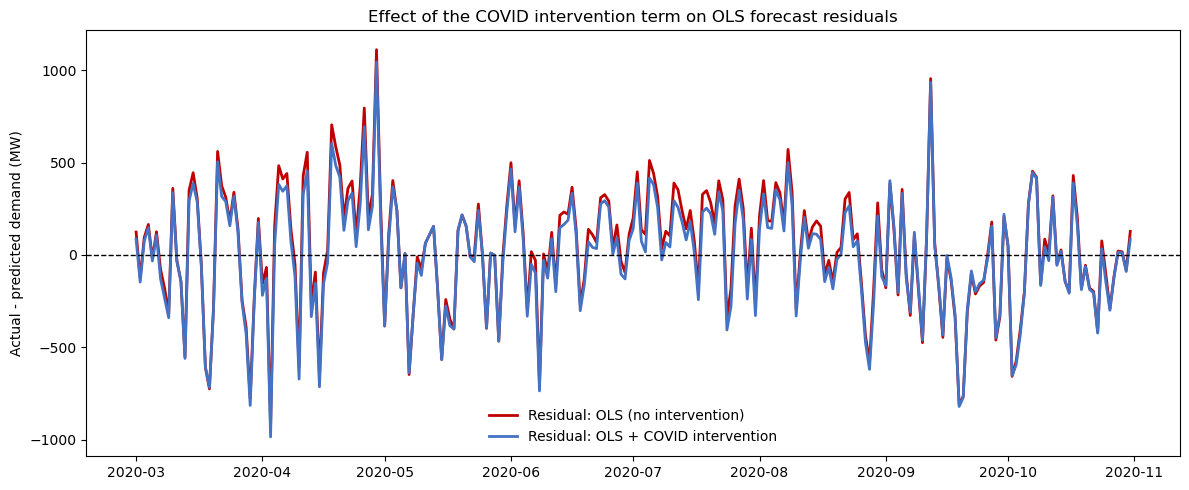

MAE  -- before: 254.0 MW, after: 238.2 MW (6% reduction)
RMSE -- before: 320.9 MW, after: 306.0 MW (5% reduction)


In [18]:
def plot_intervention_residuals_ols(df, ols, ols_covid):
    covid_df = df[(df["date"] >= COVID_START) & (df["date"] <= COVID_END)].copy()

    covid_df["residual_before"] = covid_df["max_demand_mw"] - ols.predict(covid_df)
    covid_df["residual_after"] = covid_df["max_demand_mw"] - ols_covid.predict(covid_df)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(covid_df["date"], covid_df["residual_before"], color="#C00000", linewidth=2,
            label="Residual: OLS (no intervention)")
    ax.plot(covid_df["date"], covid_df["residual_after"], color="#4472C4", linewidth=2,
            label="Residual: OLS + COVID intervention")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Effect of the COVID intervention term on OLS forecast residuals")
    ax.set_ylabel("Actual - predicted demand (MW)")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("covid_intervention_residuals_ols.png", dpi=150)
    plt.show()

    mae_before = covid_df["residual_before"].abs().mean()
    mae_after = covid_df["residual_after"].abs().mean()
    rmse_before = (covid_df["residual_before"] ** 2).mean() ** 0.5
    rmse_after = (covid_df["residual_after"] ** 2).mean() ** 0.5

    print(f"MAE  -- before: {mae_before:.1f} MW, after: {mae_after:.1f} MW "
          f"({(1 - mae_after / mae_before):.0%} reduction)")
    print(f"RMSE -- before: {rmse_before:.1f} MW, after: {rmse_after:.1f} MW "
          f"({(1 - rmse_after / rmse_before):.0%} reduction)")


plot_intervention_residuals_ols(df, ols, ols_covid)

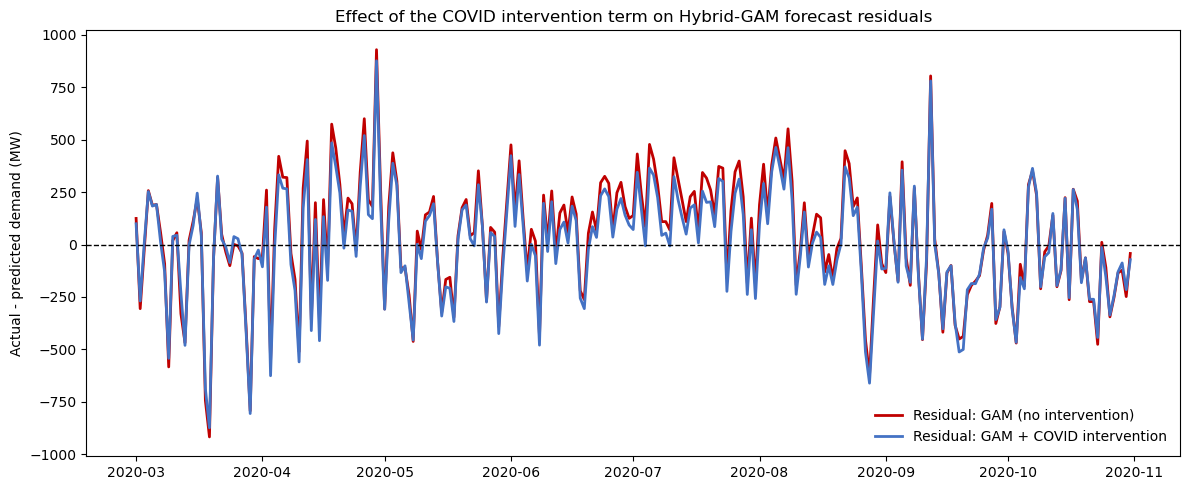

MAE  -- before: 224.9 MW, after: 204.2 MW (9% reduction)
RMSE -- before: 280.5 MW, after: 261.9 MW (7% reduction)


In [19]:
def plot_intervention_residuals(df, gam, gam_covid):
    covid_df = df[(df["date"] >= COVID_START) & (df["date"] <= COVID_END)].copy()

    covid_df["residual_before"] = covid_df["max_demand_mw"] - predict_hybrid_gam(gam, covid_df, GAM_FEATURES)
    covid_df["residual_after"] = covid_df["max_demand_mw"] - predict_hybrid_gam(gam_covid, covid_df, GAM_FEATURES_COVID)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(covid_df["date"], covid_df["residual_before"], color="#C00000", linewidth=2,
            label="Residual: GAM (no intervention)")
    ax.plot(covid_df["date"], covid_df["residual_after"], color="#4472C4", linewidth=2,
            label="Residual: GAM + COVID intervention")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Effect of the COVID intervention term on Hybrid-GAM forecast residuals")
    ax.set_ylabel("Actual - predicted demand (MW)")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("covid_intervention_residuals.png", dpi=150)
    plt.show()

    mae_before = covid_df["residual_before"].abs().mean()
    mae_after = covid_df["residual_after"].abs().mean()
    rmse_before = (covid_df["residual_before"] ** 2).mean() ** 0.5
    rmse_after = (covid_df["residual_after"] ** 2).mean() ** 0.5

    print(f"MAE  -- before: {mae_before:.1f} MW, after: {mae_after:.1f} MW "
          f"({(1 - mae_after / mae_before):.0%} reduction)")
    print(f"RMSE -- before: {rmse_before:.1f} MW, after: {rmse_after:.1f} MW "
          f"({(1 - rmse_after / rmse_before):.0%} reduction)")


plot_intervention_residuals(df, gam, gam_covid)

The clearest residual plot:

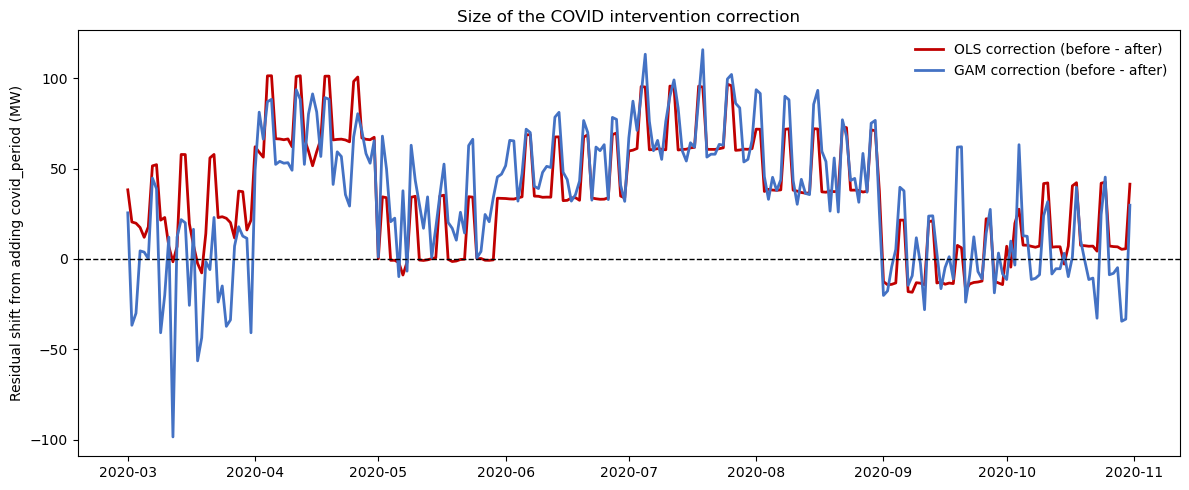

OLS correction -- mean: 34.9 MW, std: 31.1 MW
GAM correction -- mean: 34.5 MW, std: 37.2 MW


In [20]:
def plot_intervention_correction_size(df, ols, ols_covid, gam, gam_covid):
    covid_df = df[(df["date"] >= COVID_START) & (df["date"] <= COVID_END)].copy()

    ols_before = covid_df["max_demand_mw"] - ols.predict(covid_df)
    ols_after = covid_df["max_demand_mw"] - ols_covid.predict(covid_df)
    gam_before = covid_df["max_demand_mw"] - predict_hybrid_gam(gam, covid_df, GAM_FEATURES)
    gam_after = covid_df["max_demand_mw"] - predict_hybrid_gam(gam_covid, covid_df, GAM_FEATURES_COVID)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(covid_df["date"], ols_before - ols_after, color="#C00000", linewidth=2,
            label="OLS correction (before - after)")
    ax.plot(covid_df["date"], gam_before - gam_after, color="#4472C4", linewidth=2,
            label="GAM correction (before - after)")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Size of the COVID intervention correction")
    ax.set_ylabel("Residual shift from adding covid_period (MW)")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("covid_intervention_correction_size.png", dpi=150)
    plt.show()

    print(f"OLS correction -- mean: {(ols_before - ols_after).mean():.1f} MW, std: {(ols_before - ols_after).std():.1f} MW")
    print(f"GAM correction -- mean: {(gam_before - gam_after).mean():.1f} MW, std: {(gam_before - gam_after).std():.1f} MW")


plot_intervention_correction_size(df, ols, ols_covid, gam, gam_covid)

### More on Forecasting Error - A Summary in Chart Form

Below we can see the impact of correcting for COVID vs allowing a non-linear relationship between demand and weather. 

- OLS → GAM (no intervention): MAE drops 254.0 → 224.9, a 29.1 MW improvement. RMSE drops 320.9 → 280.5, a 40.4 MW improvement.
- Adding the COVID dummy within OLS: MAE drops 254.0 → 238.2, a 15.8 MW improvement. Within GAM: 224.9 → 204.2, a 20.7 MW improvement.

**Conclusion: switching to a nonlinear weather response bought you roughly 1.5–2x the error reduction that explicitly modeling COVID did, on both metrics!**

Note that in practice, these are not competing models. It is best to have both the GAM correction and the COVID correction.

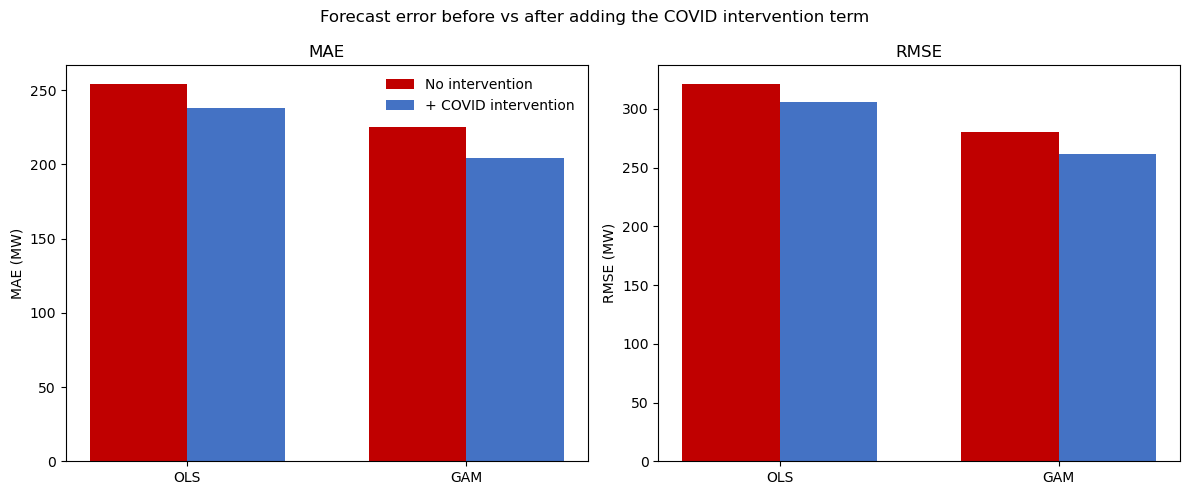

  model  MAE_before  MAE_after  RMSE_before  RMSE_after
0   OLS       254.0      238.2        320.9       306.0
1   GAM       224.9      204.2        280.5       261.9


In [21]:
def plot_intervention_metric_bars(df, ols, ols_covid, gam, gam_covid):
    covid_df = df[(df["date"] >= COVID_START) & (df["date"] <= COVID_END)].copy()

    ols_before = covid_df["max_demand_mw"] - ols.predict(covid_df)
    ols_after = covid_df["max_demand_mw"] - ols_covid.predict(covid_df)
    gam_before = covid_df["max_demand_mw"] - predict_hybrid_gam(gam, covid_df, GAM_FEATURES)
    gam_after = covid_df["max_demand_mw"] - predict_hybrid_gam(gam_covid, covid_df, GAM_FEATURES_COVID)

    metrics = pd.DataFrame({
        "model": ["OLS", "GAM"],
        "MAE_before": [ols_before.abs().mean(), gam_before.abs().mean()],
        "MAE_after": [ols_after.abs().mean(), gam_after.abs().mean()],
        "RMSE_before": [(ols_before ** 2).mean() ** 0.5, (gam_before ** 2).mean() ** 0.5],
        "RMSE_after": [(ols_after ** 2).mean() ** 0.5, (gam_after ** 2).mean() ** 0.5],
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(metrics))
    width = 0.35

    for ax, metric in zip(axes, ["MAE", "RMSE"]):
        ax.bar(x - width / 2, metrics[f"{metric}_before"], width, label="No intervention", color="#C00000")
        ax.bar(x + width / 2, metrics[f"{metric}_after"], width, label="+ COVID intervention", color="#4472C4")
        ax.set_xticks(x)
        ax.set_xticklabels(metrics["model"])
        ax.set_title(metric)
        ax.set_ylabel(f"{metric} (MW)")

    axes[0].legend(frameon=False)
    fig.suptitle("Forecast error before vs after adding the COVID intervention term")
    plt.tight_layout()
    plt.savefig("covid_intervention_metric_bars.png", dpi=150)
    plt.show()

    return metrics


metric_summary = plot_intervention_metric_bars(df, ols, ols_covid, gam, gam_covid)
print(metric_summary.round(1))

## Quantifying Uncertainty: POE10 / POE50 / POE90 Across Models

I include this only as an example of how to calculate/interpret POE bands. These bands come from a thin sample: the 3 pre-COVID weather years (2017-2019).

Note in these scenarios, we set the fixed-effect coefficient `covid_period` to 0. Aka, "What would demand in a normal 2020 look like?"

The bands can be read left to right as roughly low-to-high risk. POE90 is the demand level you'd expect to exceed almost always (a conservative planning floor), POE50 is the median best-guess peak, and POE10 is the demand level you'd only expect to exceed 10% of the time. Note that unlike AEMO's POEs, these also don't include other causes of uncertainty - economic growth, electric vehicle uptake, structural shocks beyond COVID, etc.

### Interpreting the graph

The actual bands above show a real difference between the two models. **The Hybrid-GAM's range (8,504–9,110 MW) sits both lower and roughly half as wide as OLS's (8,360–9,523 MW) — meaning GAM is expressing more confidence in a narrower outcome, not just a different central estimate.** The OLS+COVID counterfactual band sits close to plain OLS but shifted slightly lower; this is the omitted-variable-bias effect we saw earlier, where adding the COVID dummy slightly changes the other estimated coefficients even when `covid_period` is held at 0.

Worth flagging: the Hybrid GAM model smooths the weather terms, dampening the influence of any single extreme day across the three sampled years. With less variation, the Hybrid-GAM may have inflated confidence. This is something to be conscious of when working with machine learning models.

Generating POE distributions...
                          model   POE10   POE50   POE90
0                           OLS  9523.0  9442.7  8360.0
1                    Hybrid-GAM  9110.2  9012.2  8503.7
2  OLS + COVID (counterfactual)  9434.5  9338.2  8273.4


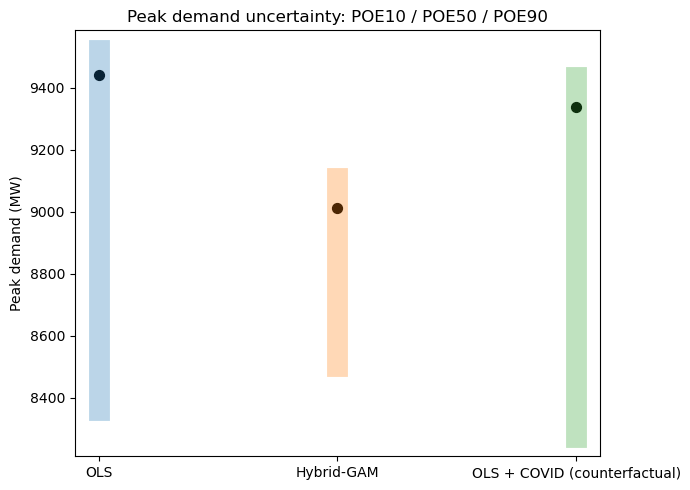

In [26]:
print("Generating POE distributions...")
poe_results = []
for name, model, kind in [
    ("OLS", ols, "ols"),
    ("Hybrid-GAM", gam, "gam"),
    ("OLS + COVID (counterfactual)", ols_covid, "ols"),
]:
    poe = simulate_peak_distribution(model, train, 2020, model_type=kind)
    poe_results.append({"model": name, **poe})

poe_df = pd.DataFrame(poe_results)
print(poe_df.round(1))
plot_poe(poe_results)


## Quantifying Leftover Nonlinearity: Quadratic Check on OLS and GAM Residuals

A numeric companion to the residual-vs-weather plots above: does adding squared HDD/CDD terms explain a meaningful share of what's left in the residuals? Squared terms are a traditional way to let OLS capture curvature without abandoning the linear regression framework - the model stays linear in its coefficients, even though the predictor itself (HDD², CDD²) is a nonlinear transform of the original variable.

OLS residuals still carry a statistically significant, if modest, amount of leftover nonlinear signal. Adding HDD²/CDD² explains 5.8% of what OLS's residuals couldn't. **Running the same check on GAM's residuals explains essentially 0.0% — direct evidence that GAM's smooth terms are capturing the nonlinearity that OLS, even with a basic quadratic fix, still misses.**

In [23]:
train_check = train.copy()
train_check["residual"] = train_check["max_demand_mw"] - ols.predict(train_check)

residual_model = smf.ols(
    "residual ~ hdd + cdd + I(hdd**2) + I(cdd**2)", data=train_check
).fit()

print(f"R-squared of residuals explained by quadratic weather terms: {residual_model.rsquared:.4f}")
print(f"F-test p-value: {residual_model.f_pvalue:.4g}")

R-squared of residuals explained by quadratic weather terms: 0.0584
F-test p-value: 1.832e-13


In [24]:
train_check_gam = train.copy()
train_check_gam["residual"] = train_check_gam["max_demand_mw"] - predict_hybrid_gam(gam, train_check_gam, GAM_FEATURES)

residual_model_gam = smf.ols(
    "residual ~ hdd + cdd + I(hdd**2) + I(cdd**2)", data=train_check_gam
).fit()

print(f"R-squared of GAM residuals explained by quadratic weather terms: {residual_model_gam.rsquared:.4f}")
print(f"F-test p-value: {residual_model_gam.f_pvalue:.4g}")

R-squared of GAM residuals explained by quadratic weather terms: 0.0000
F-test p-value: 1


In [25]:

# Sanity check - these all being approximately 0 shows our previous value is not a bug.
print(train_check_gam["residual"].describe())


count    1.095000e+03
mean     8.047216e-08
std      3.564549e+02
min     -1.561129e+03
25%     -1.831561e+02
50%      1.611866e+01
75%      1.977843e+02
max      1.317700e+03
Name: residual, dtype: float64


## Summary: Sources of Uncertainty

| Source of uncertainty | Method |
|---|---|
| Weather variability | Historical weather-year resampling |
| Model uncertainty | OLS vs GAM comparison |
| Structural uncertainty | COVID intervention scenario |

## Summary: Model Strengths and Failure Modes



 | Model | Strength | Failure mode |
 |---|---|---|
 | OLS | Interpretable, stable | Misses nonlinear weather response |
 | GAM | Captures nonlinear effects | Cannot infer external behavioural shocks |
 | Intervention model | Adapts to known events | Requires domain knowledge |